# This project consists of three main parts: EDA, model building, evaluation of models outputs.
## The structure of this notebook:
* [EDA](https://)
* [Model creation](https://)
* [Evaluation](https://)







## We will start with EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from scipy import stats
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [ ]:
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
# print(heart_disease.metadata)

# variable information
# print(heart_disease.variables)


# print(X.head())
# print(y.head())

print(f'Shape of X: {X.shape}\nShape of y: {y.shape}')
# y = pd.Series(y['num'], name='HD')

# print(y.unique())

Shape of X: (303, 13)
Shape of y: (303, 1)


Because it's not very convinient to do EDA with two DataFrames X and y we will combine them into one DataFrame df, explore its values and later on train our classification models.

In [ ]:
df = X.merge(y, how='left', left_index=True, right_index=True)
print(f'First look at our combined DataFrame:\n{df.head()}')

First look at our combined DataFrame:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


Now let's see shape of our DataFrame. Previously we saw that X had a shape of (303,13) and y had a shape of (303,1). That means that our combined df must have a shape of (303,14).

In [ ]:
print(f'Combined DataFrame shape: {df.shape}')

Combined DataFrame shape: (303, 14)


As we anticipated we have got a shape of (303,14). Now let's look at columns that our df contains.

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Now let's check data types of columns, whether they contain missing values and if we can make our dataset lighter using

```
df.info()
```



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
ca,4
thal,2
cp,0
trestbps,0
age,0
sex,0
fbs,0
chol,0
restecg,0
thalach,0


Our dataset contains of columns mostly in int64 type and we have three columns of type float 64. Because the dataset is very small I don't see a need in changing data types(if there's a need than we could use int16 and float 16 instead. We would do such changes if our dataset contained millions of rows). We have 2 columns with missing values: ca and thal. We need to check this missing values.

<Axes: >

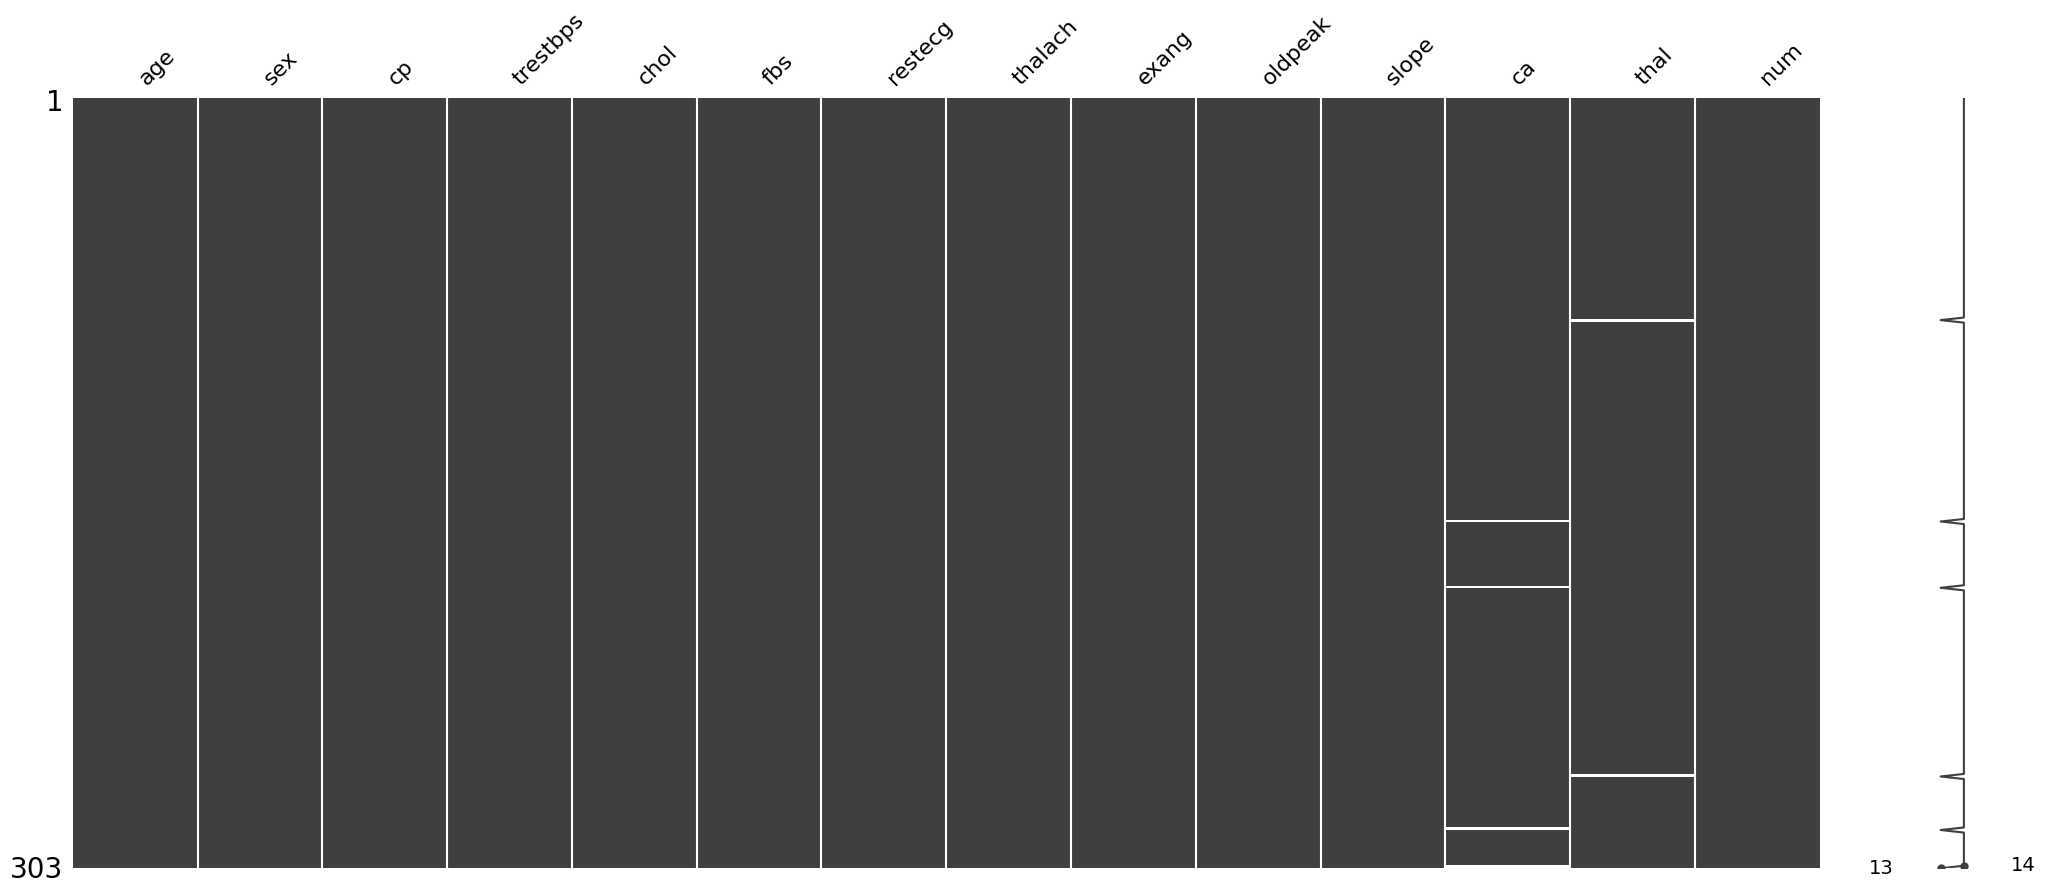

In [ ]:
msno.matrix(df)

After plotting a matrix of missing values in our DataFrame I don't see a clear pattern in them which means that they are probably unrelated to each other. Now I want to see this rows of missing values and calculate their percentage.

In [ ]:
print(f'Missing values: {df[df.isna().any(axis=1)]}')
print(f'Percentage of missing values: {sorted(df.isna().sum()/len(df)*100, reverse=True)}')

Missing values:      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
87    53    0   3       128   216    0        2      115      0      0.0   
166   52    1   3       138   223    0        0      169      0      0.0   
192   43    1   4       132   247    1        2      143      1      0.1   
266   52    1   4       128   204    1        0      156      1      1.0   
287   58    1   2       125   220    0        0      144      0      0.4   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
87       1  0.0   NaN    0  
166      1  NaN   3.0    0  
192      2  NaN   7.0    1  
266      2  0.0   NaN    2  
287      2  NaN   7.0    0  
302      1  NaN   3.0    0  
Percentage of missing values: [1.3201320132013201, 0.6600660066006601, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


We could impute our missing values with a median, but a more reasonable approach here would be to drop this values as their percentage is less than 5% of our DataFrame length.

In [ ]:
# We should be really careful with inplace=True because we change our original DataFrame(in most situations it is preferred to copy new values into a new DataFrame)
df.dropna(axis=0, inplace=True)
print(f'Number of missing values in each column: {df.isna().sum()}')
print(f'Shape of DataFrame: {df.shape}')

Number of missing values in each column: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
Shape of DataFrame: (297, 14)


In [ ]:
y = df['num']
y = y.mask(y>0, 1)
y.unique()

array([0, 1])

Now I want to check wether columns contain any unreasonable values.

In [ ]:
for column in df.columns:
  print(f'{column} contains: {df[column].unique()}')

age contains: [63 67 37 41 56 62 57 53 44 52 48 54 49 64 58 60 50 66 43 40 69 59 42 55
 61 65 71 51 46 45 39 68 47 34 35 29 70 77 38 74 76]
sex contains: [1 0]
cp contains: [1 4 3 2]
trestbps contains: [145 160 120 130 140 172 150 110 132 117 135 112 105 124 125 142 128 170
 155 104 180 138 108 134 122 115 118 100 200  94 165 102 152 101 126 174
 148 178 158 192 129 144 123 136 146 106 156 154 114 164]
chol contains: [233 286 229 250 204 236 268 354 254 203 192 294 256 263 199 168 239 275
 266 211 283 284 224 206 219 340 226 247 167 230 335 234 177 276 353 243
 225 302 212 330 175 417 197 198 290 253 172 273 213 305 216 304 188 282
 185 232 326 231 269 267 248 360 258 308 245 270 208 264 321 274 325 235
 257 164 141 252 255 201 222 260 182 303 265 309 307 249 186 341 183 407
 217 288 220 209 227 261 174 281 221 205 240 289 318 298 564 246 322 299
 300 293 277 214 207 160 394 184 315 409 244 195 196 126 313 259 200 262
 215 228 193 271 210 327 149 295 306 178 237 218 223 242 319 166 180

All values are numbers.

Descriptive statistic

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


# Finding duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

0 duplicates

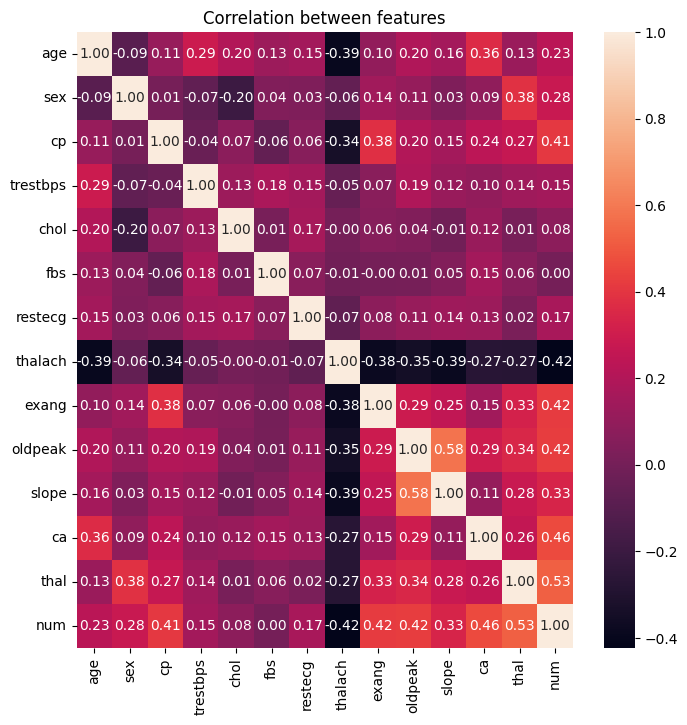

In [ ]:
heatmap_df = df.copy()
heatmap_df['num'] = y
corelation_matrix = heatmap_df.corr()
plt.figure(figsize=(8,8))
sns.heatmap(corelation_matrix, annot=True, fmt='.2f')
plt.title('Correlation between features')
plt.show()

The biggest correlation with num is cp(0.4), thalach(-0.42), exang(0.39), oldpeak(0.5), slope(0.37), ca(0.52), thal(0.51). Note: explain that dataset consists only from the most important features that's why we don't use Lasso and why we need to examine at least features with the biggest correlation. Correlation - only linear dependency.

### The important note here is that this dataset consists only from the most important features that were selected for us. What else is concerning here is the correlation between slope and oldpeak features. That is it has a value of 0.58. So we would like to check with some additional tests whether this two features are strongly correlated.

In [ ]:
groups = [df[df['slope'] == level]['oldpeak'] for level in df['slope'].unique()]
h_stat, p_val = stats.kruskal(*groups)
print(f'H-statistic: {h_stat:.3f}, p-value: {p_val}')

H-statistic: 104.314, p-value: 2.2306512643267478e-23


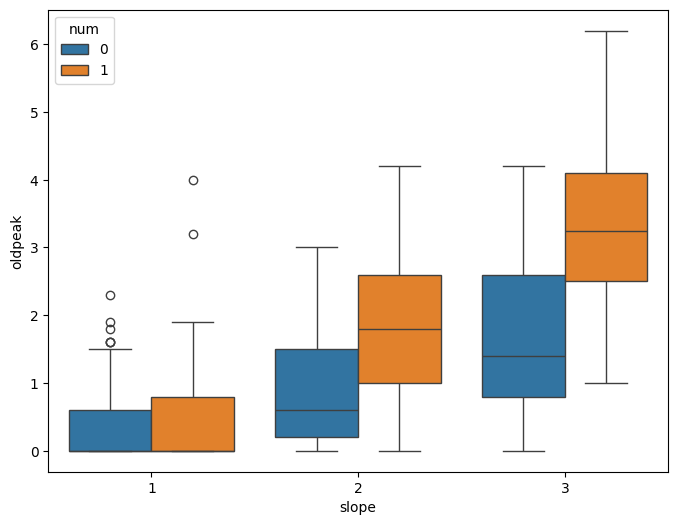

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=heatmap_df, x='slope', y='oldpeak', hue=y)
plt.show()

In [ ]:
categorical = ['cp', 'sex', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Text(0.5, 0.98, 'Class disbalance in "num"')

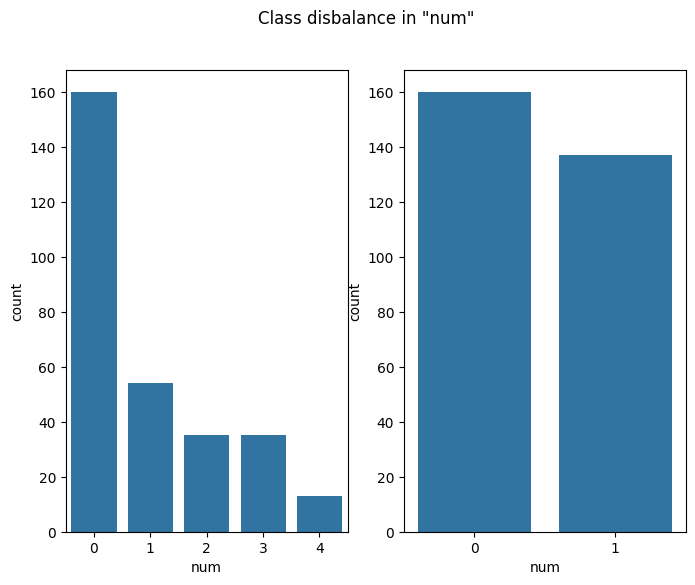

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6))
sns.countplot(data=df, x='num', ax=ax[0])
sns.countplot(x=y, ax=ax[1])
plt.suptitle('Class disbalance in "num"')

Building continuous plots

In [ ]:
def plot_continuous_features(df, x, y):
  fig, ax = plt.subplots(1,2, figsize=(10,6))
  sns.histplot(data=df, x=y, ax=ax[0], kde=True)
  sns.boxplot(data=df, x=x, y=y, ax=ax[1], hue=x)
  plt.suptitle(f"{y.title()} distribution plot")
  plt.show()

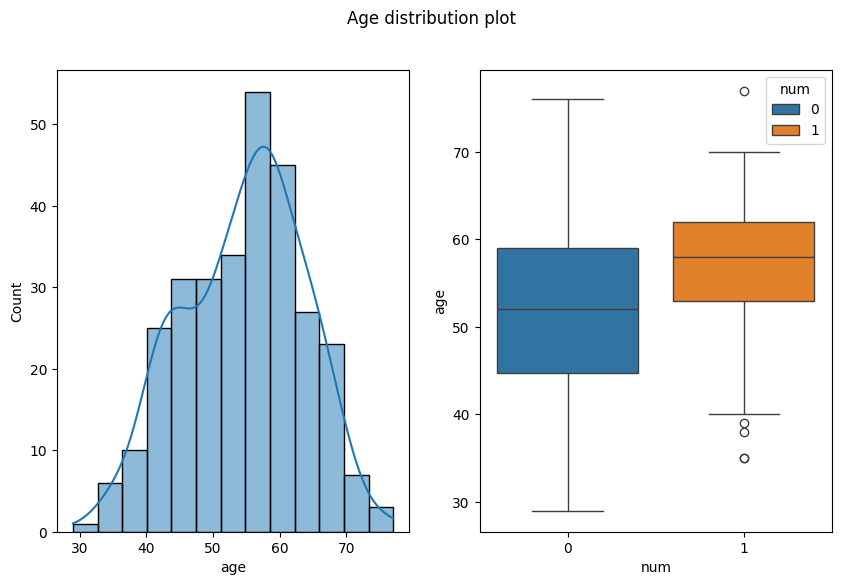

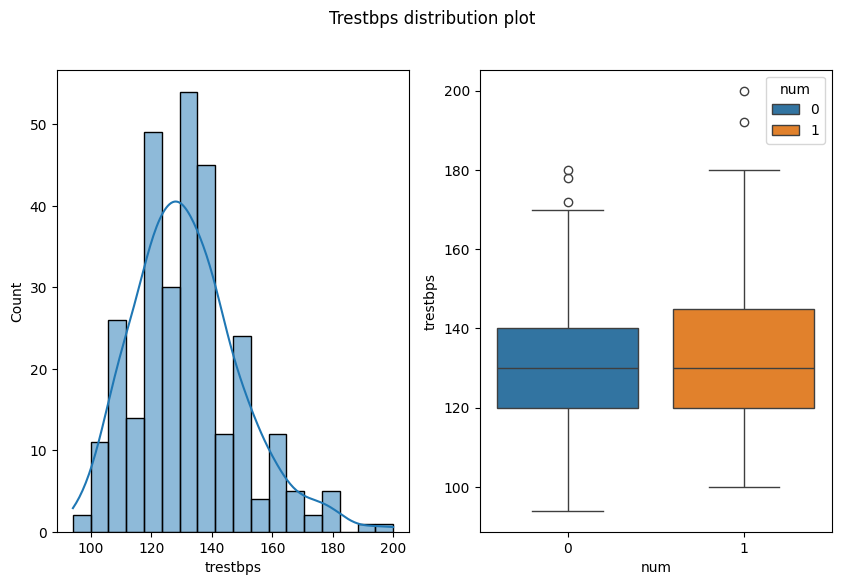

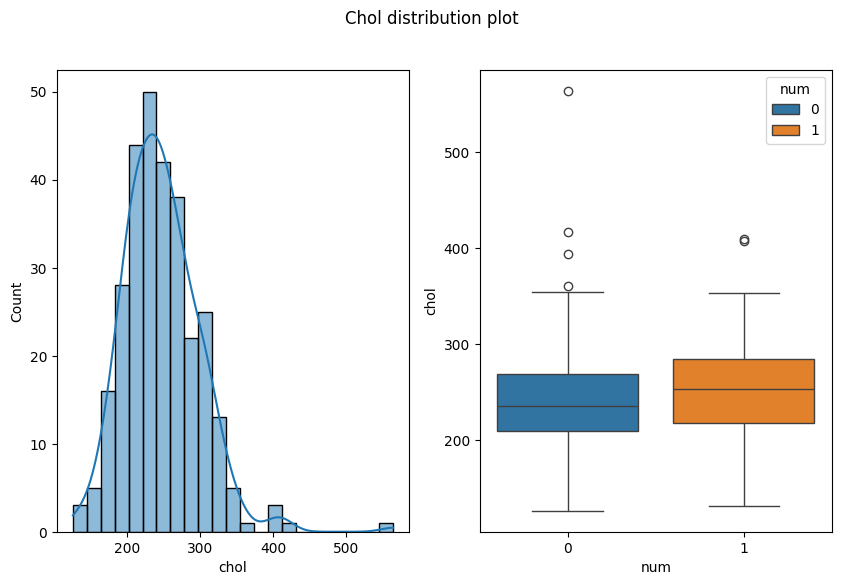

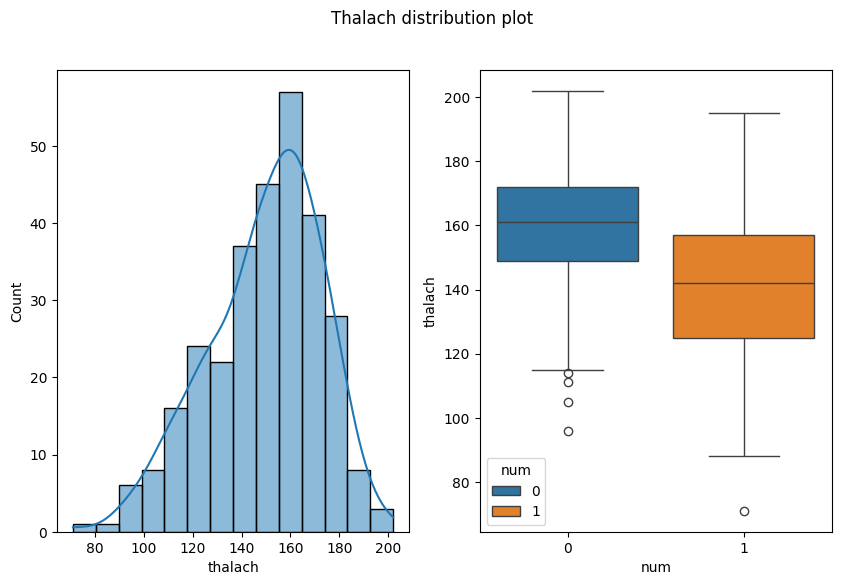

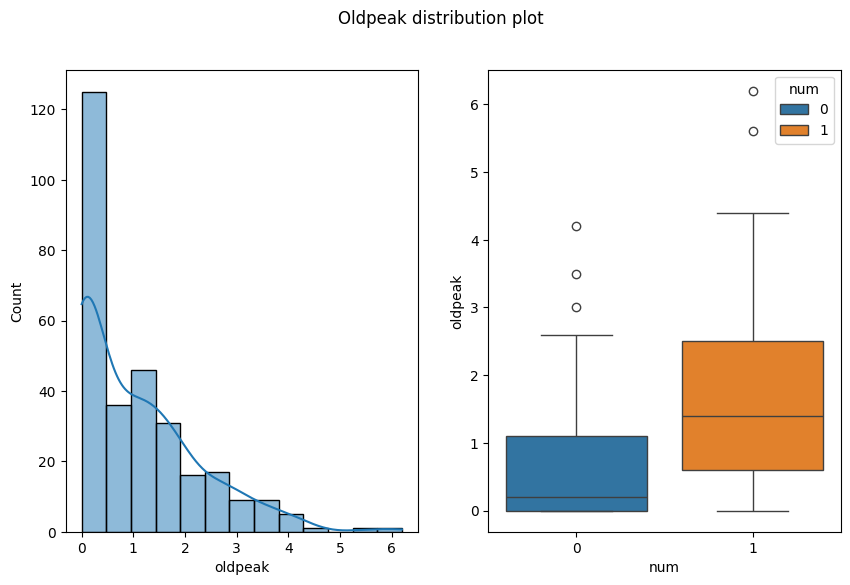

In [ ]:
for feature in continuous:
  plot_continuous_features(df, y=feature, x=y)

In [ ]:
def plot_categorical_features(df, x, y):
  fig, ax = plt.subplots(1, 2, figsize=(10, 6))
  sns.countplot(data=df, x=x, ax=ax[0])
  sns.barplot(data=df, x=x, y=y, ax=ax[1])
  plt.show()

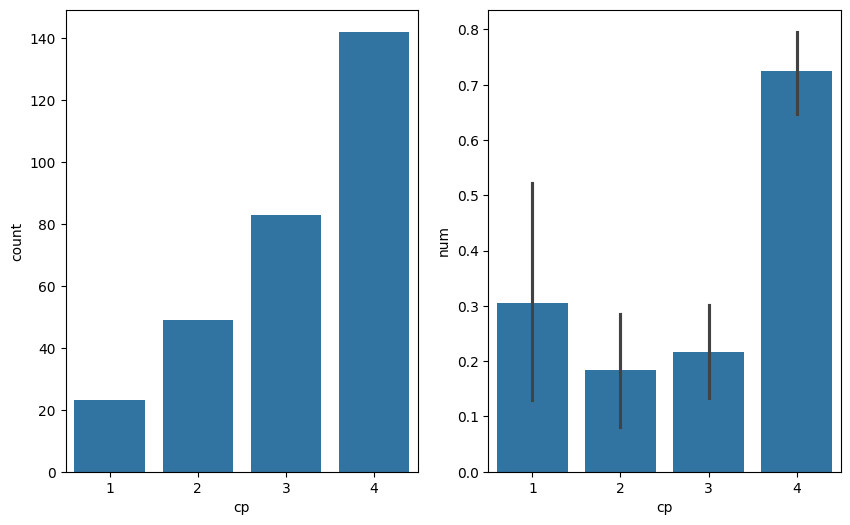

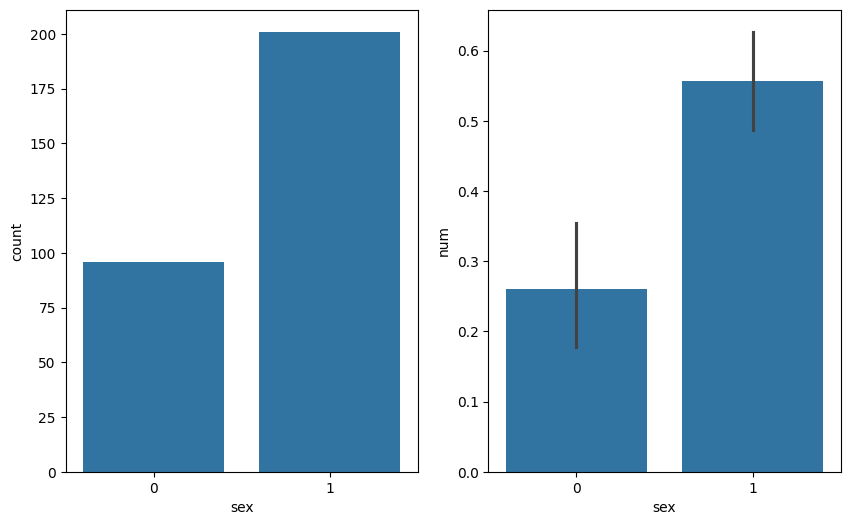

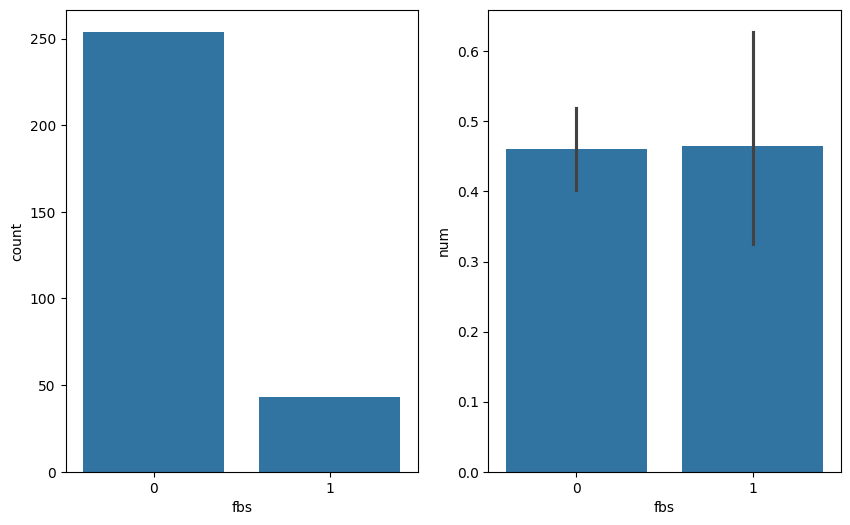

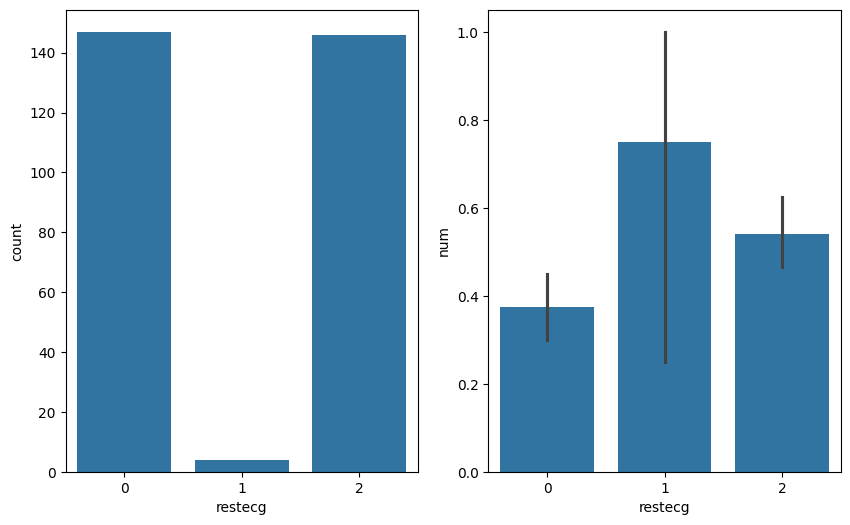

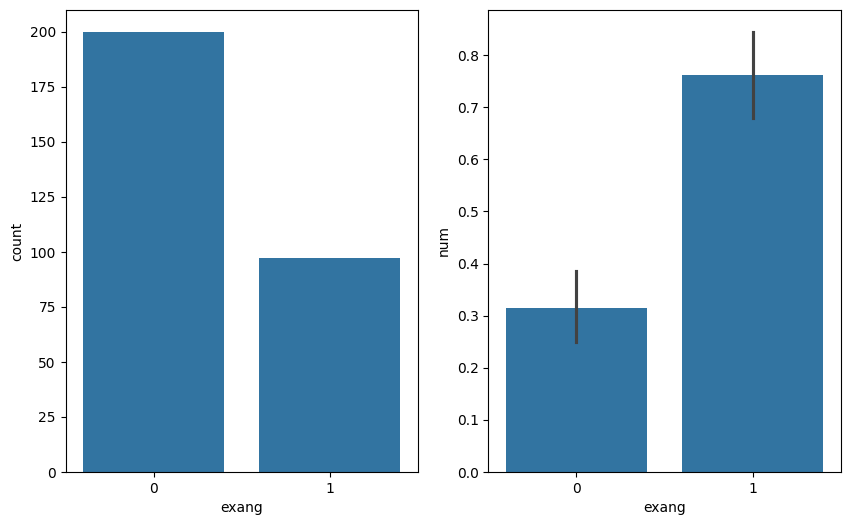

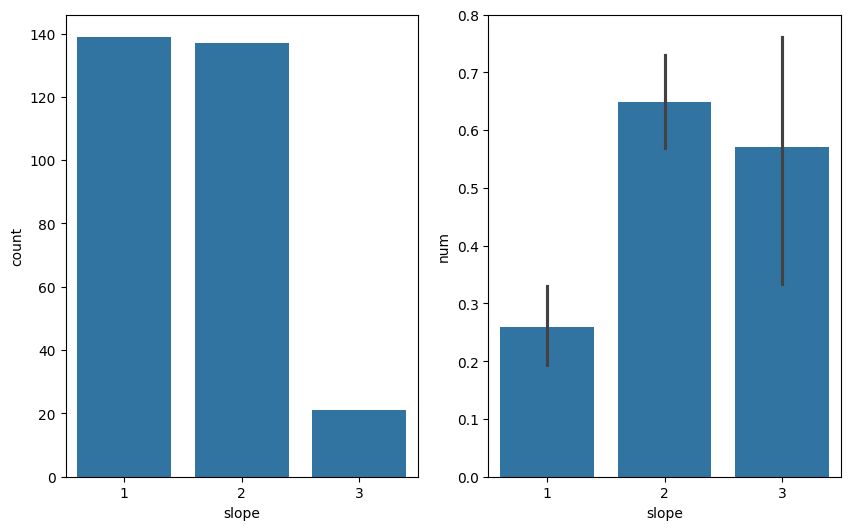

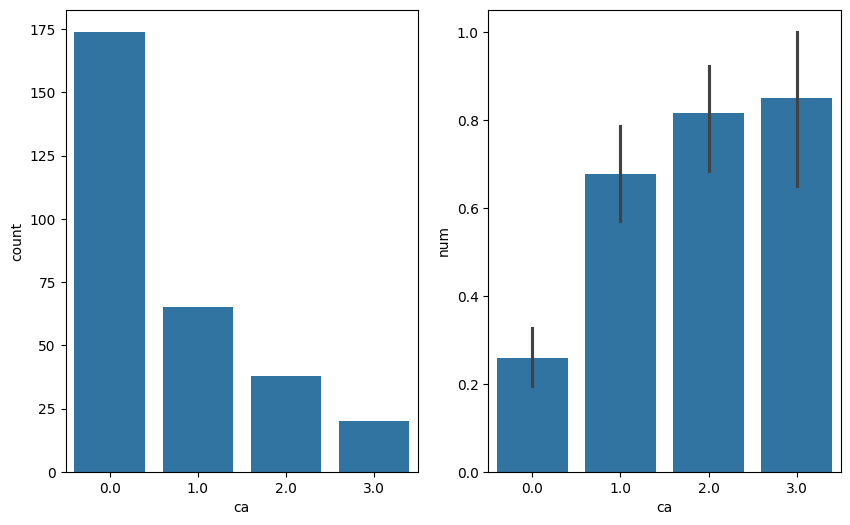

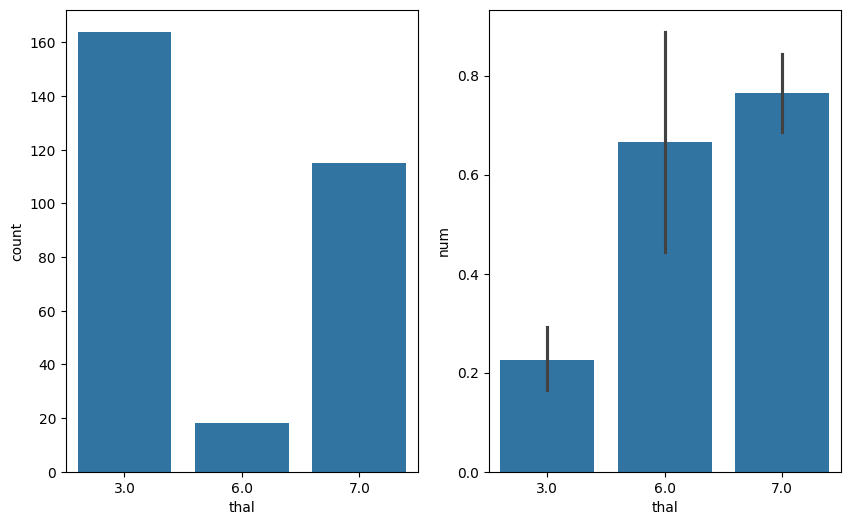

In [ ]:
for feature in categorical:
  plot_categorical_features(df, feature, y)

### Worth noticing:
The distribution between males and females is highly skewed. That is there are around 60% of males and only 40% of females which may lead to our models missjugment.

The plot for thalach is left skewed and for old peak is right skewed, nevertheless thalach plot resembales normal distribution which is good. Plot for oldpeak looks like Chi^2 distribution.

In [ ]:


for col in continuous:
  stat, p_val = stats.shapiro(df[col])
  print(f'{col}: Shapiro_Wilk-> {stat:.2f}, p_value-> {p_val}. {'Normal' if p_val > 0.05 else 'Not normal'}')

age: Shapiro_Wilk-> 0.99, p_value-> 0.00542394963252737. Not normal
trestbps: Shapiro_Wilk-> 0.97, p_value-> 2.416417410498496e-06. Not normal
chol: Shapiro_Wilk-> 0.95, p_value-> 1.0190566722567511e-08. Not normal
thalach: Shapiro_Wilk-> 0.98, p_value-> 9.043932259094454e-05. Not normal
oldpeak: Shapiro_Wilk-> 0.85, p_value-> 2.0404335944109574e-16. Not normal


## As all our features are not normally distributed we would use Mann-Whitneys test

In [ ]:
test_results = []

for col in continuous:
  group0 = df[y==0][col]
  group1 = df[y==1][col]
  stat, p_val = stats.mannwhitneyu(group0, group1, alternative='two-sided')
  test_results.append({'feature':col,
                       'test': 'Mann-Whitney',
                       'stat':stat,
                       'p_value':p_val})
continuous_res_df = pd.DataFrame(test_results)
continuous_res_df

,feature,test,stat,p_value
0,age,Mann-Whitney,7916.5,3.672541e-05
1,trestbps,Mann-Whitney,9292.5,2.345960e-02
2,chol,Mann-Whitney,9492.0,4.668918e-02
3,thalach,Mann-Whitney,16399.0,1.675290e-13
4,oldpeak,Mann-Whitney,5833.5,1.538610e-12


## Categorical features tests

In [ ]:
categorical_results = []

for col in categorical:
  contingency = pd.crosstab(df[col], y)
  chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
  min_expected = round(expected.min())
  n = contingency.sum().sum()
  cramer_v = np.sqrt((chi2/n)/(np.min(contingency.shape)-1))

  categorical_results.append({
        'feature': col,
        'chi2': chi2,
        'p_value': p_val,
        'dof': dof,
        'min_expected_count': min_expected,
        'reliable': min_expected >= 5,
        'cramer\'s V': cramer_v
    })

cat_df = pd.DataFrame(categorical_results)
cat_df

,feature,chi2,p_value,dof,min_expected_count,reliable,cramer's V
0,cp,77.275800,1.178284e-16,3,11,True,0.510086
1,sex,21.851612,2.945690e-06,1,44,True,0.271246
2,fbs,0.000000,1.000000e+00,1,20,True,0.000000
3,restecg,9.575507,8.331151e-03,2,2,False,0.179557
4,exang,50.942560,9.510884e-13,1,45,True,0.414154
5,slope,43.473178,3.630107e-10,2,10,True,0.382589
6,ca,72.300531,1.372578e-15,3,9,True,0.493392
7,thal,82.460144,1.241673e-18,2,8,True,0.526919


# Summary of EDA

## We gained a lot of new information thanks to this exploratiry data analysis and now we can answer our main questions:
1.
2.
3.

# Also worth to being noticed:

# Building models

# План:
1. Побудувати графіки й візуалізацію всю необхідну
2. Провести статистичні тести
3. Дати відповіді на найбільш важливі питання
4. Побудувати всі моделі та проаналізувати їхні виводи

# Моделі
1. Побудувати моделі
2. Побудувати просту нейромережу
3. Визначити точності моделей
4. Побудувати графіки моделей за можливості

## We will start with logistic regression

The class imbalance is not that high, but because the dataset is really small I would like to use weighted models.

In [ ]:
X_model = df.drop(columns=['num'], axis=1)
X_model = pd.get_dummies(X_model, columns=['cp', 'restecg', 'slope', 'ca', 'thal'], drop_first=True)
y_model = y
X_model.head(), y_model.head()

(   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak   cp_2   cp_3  \
 0   63    1       145   233    1      150      0      2.3  False  False   
 1   67    1       160   286    0      108      1      1.5  False  False   
 2   67    1       120   229    0      129      1      2.6  False  False   
 3   37    1       130   250    0      187      0      3.5  False   True   
 4   41    0       130   204    0      172      0      1.4   True  False   
 
     cp_4  restecg_1  restecg_2  slope_2  slope_3  ca_1.0  ca_2.0  ca_3.0  \
 0  False      False       True    False     True   False   False   False   
 1   True      False       True     True    False   False   False    True   
 2   True      False       True     True    False   False    True   False   
 3  False      False      False    False     True   False   False   False   
 4  False      False       True    False    False   False   False   False   
 
    thal_6.0  thal_7.0  
 0      True     False  
 1     False     False  
 2 

In [ ]:
scaler = StandardScaler()
X_model = np.array(X_model)
y_model = np.array(y_model)


X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, shuffle=True, random_state=12)
print(X_train.shape, y_train.shape)

(237, 20) (237,)


In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
scores = []
summary_stat_model = []

### Fiting a model

In [ ]:
log_reg = LogisticRegression(class_weight='balanced', random_state=12)

In [ ]:
def plot_conf_matrix(y_true, y_pred):
  confusion_mat = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_mat)
  disp.plot()
  plt.show()

def cross_val_model(model, X, y)->list:
  return cross_val_score(model, X, y, cv=5)

In [ ]:
log_reg = log_reg.fit(X_train, y_train)
log_reg_score = round(log_reg.score(X_test, y_test),2)
log_reg_score

0.88

In [ ]:
log_reg_preds = log_reg.predict(X_test)

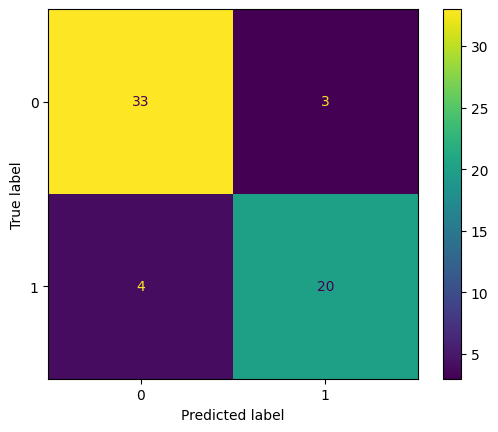

In [ ]:
plot_conf_matrix(y_test, log_reg_preds)

In [ ]:
print(classification_report(y_test, log_reg_preds))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.87      0.83      0.85        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [ ]:
perf = cross_val_model(log_reg, X_train, y_train)
scores.append(['Logistic_Regression',
               round(np.mean(perf),2),
               round(np.std(perf),2)])
scores

[['Logistic_Regression', np.float64(0.78), np.float64(0.08)]]

Could be way better

In [ ]:
dt = DecisionTreeClassifier(random_state=12)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

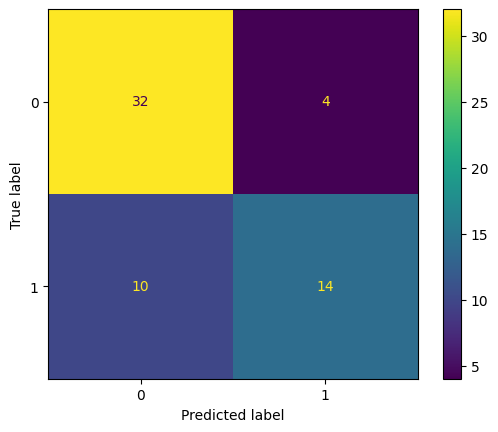

In [ ]:
plot_conf_matrix(y_test, dt_preds)

In [ ]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.76      0.89      0.82        36
           1       0.78      0.58      0.67        24

    accuracy                           0.77        60
   macro avg       0.77      0.74      0.74        60
weighted avg       0.77      0.77      0.76        60



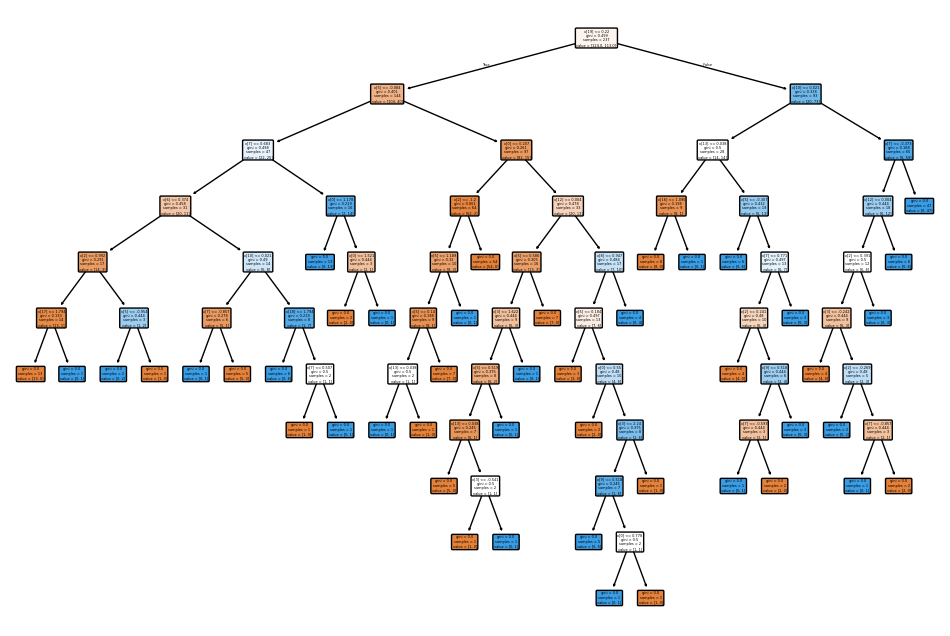

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, rounded=True)
plt.show()

## Tree pruning

In [ ]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]

dt_alphas = []
for ccp_alpha in ccp_alphas:
  tree = DecisionTreeClassifier(random_state=12, ccp_alpha=ccp_alpha)
  score = cross_val_score(tree, X_train, y_train, cv=5)
  dt_alphas.append([ccp_alpha, np.mean(score), np.std(score)])

alphas_perf_df = pd.DataFrame(dt_alphas, columns=['alpha', 'mean_score', 'std'])
alphas_perf_df

,alpha,mean_score,std
0,0.000000,0.721099,0.051134
1,0.003617,0.721099,0.051134
2,0.003617,0.721099,0.051134
3,0.003692,0.721099,0.051134
4,0.003751,0.721099,0.051134
5,0.004425,0.721099,0.051134
6,0.004445,0.721099,0.051134
7,0.005063,0.712677,0.061120
8,0.005425,0.716844,0.065496
9,0.005626,0.716844,0.065496


In [ ]:
best_alpha_idx = alphas_perf_df['mean_score'].idxmax(axis=0)
best_alpha = alphas_perf_df['alpha'].iloc[best_alpha_idx]
best_alpha

np.float64(0.007032348804500704)

In [ ]:
final_tree = DecisionTreeClassifier(random_state=12, ccp_alpha=best_alpha)
final_tree = final_tree.fit(X_train, y_train)

final_tree_preds = final_tree.predict(X_test)

final_tree_score = cross_val_score(final_tree, X_train, y_train, cv=5)

scores.append(['DecisionTree Classifier', round(np.mean(final_tree_score),2), round(np.std(final_tree_score),2)])

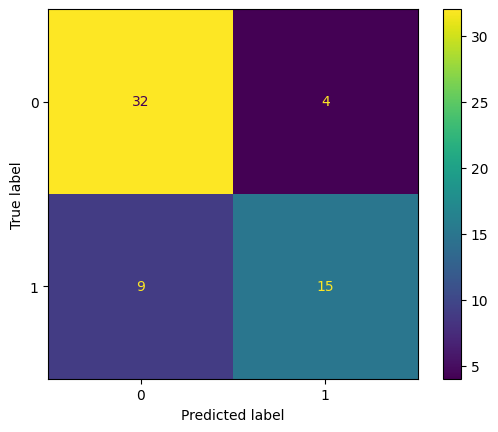

In [ ]:
plot_conf_matrix(y_test, final_tree_preds)

In [ ]:
print(classification_report(y_test, final_tree_preds))

              precision    recall  f1-score   support

           0       0.78      0.89      0.83        36
           1       0.79      0.62      0.70        24

    accuracy                           0.78        60
   macro avg       0.78      0.76      0.76        60
weighted avg       0.78      0.78      0.78        60



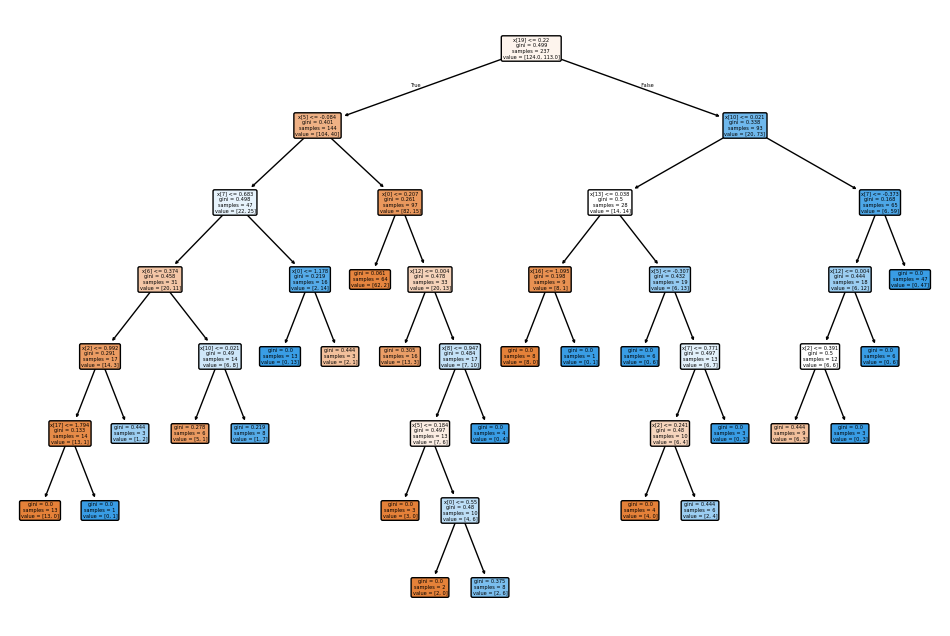

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(final_tree, filled=True, rounded=True)
plt.show()

In [ ]:
rf = RandomForestClassifier(random_state=12)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

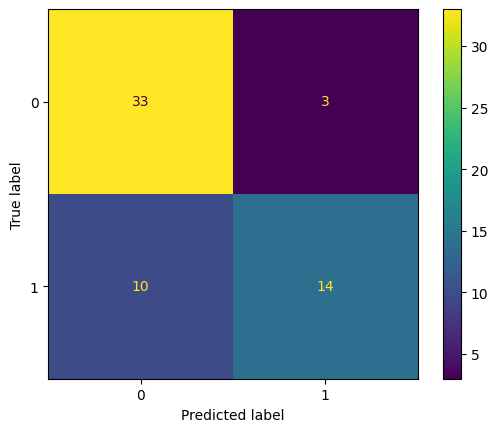

In [ ]:
plot_conf_matrix(y_test, rf_preds)

In [ ]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.77      0.92      0.84        36
           1       0.82      0.58      0.68        24

    accuracy                           0.78        60
   macro avg       0.80      0.75      0.76        60
weighted avg       0.79      0.78      0.77        60



In [ ]:
rf_scores = cross_val_score(rf, X_train, y_train, cv=5)

scores.append(['Random Forest', round(np.mean(rf_scores),2), round(np.std(rf_scores),2)])
rf_scores

array([0.79166667, 0.79166667, 0.87234043, 0.72340426, 0.82978723])

In [ ]:
scores

[['Logistic_Regression', np.float64(0.78), np.float64(0.08)],
 ['DecisionTree Classifier', np.float64(0.73), np.float64(0.05)],
 ['Random Forest', np.float64(0.8), np.float64(0.05)]]

In [ ]:

df.columns, rf.feature_importances_

(Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
        'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
       dtype='object'),
 array([0.09240044, 0.02825252, 0.07925902, 0.0795851 , 0.010605  ,
        0.14212236, 0.05780852, 0.12516697, 0.01353527, 0.01890623,
        0.07771471, 0.00132984, 0.02371896, 0.04925707, 0.00449481,
        0.02584793, 0.03055723, 0.01322025, 0.00898582, 0.11723196]))

In [ ]:
import torch
from torch import nn

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
torch.manual_seed(12)
class Neural_Model(nn.Module):
  def __init__(self, in_features, out_features, hidden_inputs=16):
    super().__init__()

    self.linear_layers = nn.Sequential(
        nn.Linear(in_features=in_features, out_features=hidden_inputs),
        nn.ReLU(),
        nn.Linear(in_features=hidden_inputs, out_features=hidden_inputs),
        nn.ReLU(),
        nn.Linear(in_features=hidden_inputs, out_features=hidden_inputs),
        nn.ReLU(),
        nn.Linear(in_features=hidden_inputs, out_features=out_features)
    )

  def forward(self, x):
    return self.linear_layers(x)

model = Neural_Model(in_features=X_model.shape[1], out_features=1, hidden_inputs=16)
model

Neural_Model(
  (linear_layers): Sequential(
    (0): Linear(in_features=20, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [ ]:
X_train = torch.from_numpy(X_train).type(torch.float)
X_test = torch.from_numpy(X_test).type(torch.float)

y_train = torch.from_numpy(y_train).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [ ]:
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
def accuracy(y_pred, y_true):
  return torch.round(100*(torch.eq(y_pred, y_true).sum()/len(y_true)))

In [ ]:
epochs = 2000

nn_scores = []

for epoch in range(epochs):
  model.train()
  logits_train = model(X_train).squeeze()
  y_pred_train = torch.round(torch.sigmoid(logits_train))

  loss = loss_fn(logits_train, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()


  model.eval()
  with torch.inference_mode():
    logits_test = model(X_test).squeeze()
    y_pred_test = torch.round(torch.sigmoid(logits_test))
    loss_test = loss_fn(logits_test, y_test)
    acc = accuracy(y_pred_test, y_test)
    nn_scores.append(loss_test)

    # if epoch%100==0:
    #   print(f'Epoch: {epoch}')
    #   print(f'Train loss: {loss.item()}')
    #   print(f'Test loss: {loss_test.item()}')
    #   print(f'Test accuracy: {acc}')

    if (nn_scores[epoch] > nn_scores[epoch-1]) & (epoch!=0):
      print(f'Final stop at epoch: {epoch},\nFinal accuracy: {acc}')
      best_loss = loss_test.item()
      print(f'Best Loss: {loss_test.item()}')
      break

Final stop at epoch: 1608,
Final accuracy: 83.0
Best Loss: 0.46612390875816345


# Evaluating our models

# Final words